# The cycle

The loop data-oriented: a frame a row a board and a field a channel, pure steps over every row at once in a table, `poll` and `push` the one edge to the bus; the tempo the loop's own.

## 1 Setup

In [1]:
from coaxial import ExecutionMode

MODE = ExecutionMode.EMULATED   # the image on Renode, the stand-in where none runs; .HARDWARE and PORT at the bench
PORT = 'COM4'

## 2 The system

Four things, and the order is the program: the bus polled into memory, the steps in table order over it, memory written back, the period kept. A step sees numbers - never a port, a timeout or a board.

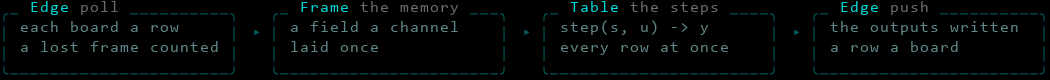

In [2]:
from machine import ansi
from machine.wiring import blocks

ansi.image(blocks([([('Edge', 'poll', ['each board a row', 'a lost frame counted']),
                     ('Frame', 'the memory', ['a field a channel', 'laid once']),
                     ('Table', 'the steps', ['step(s, u) -> y', 'every row at once']),
                     ('Edge', 'push', ['the outputs written', 'a row a board'])],
                    None)], width=24))

## 3 The boards

A limb's boards on one bus - four emulated in real time on `native://`, the stand-in's fleet simulated, your bus at the bench - each drive on its model: the demo rotor, commissioning's gains, sensorless. Renode runs the image itself, four drives at a fraction of real time; this loop's tempo is the wall's.

In [3]:
from coaxial import ExecutionMode
from coaxial.control.commission import Commissioning
from machine.nodes import Nodes

LIMB = 'native://?nodes=4&world=humanoid_leg'      # four boards on one bus, in real time
nodes = Nodes.discover(port=LIMB if MODE is ExecutionMode.EMULATED else PORT,
                       execution_mode=MODE, peripherals=())
legs = nodes.of_type('bldc_inverter')
for leg in legs:
    rig = leg.rig
    rig.drive.off()
    rig.drive.configure(source='model')
    rig.drive.model.configure(j=8e-3, b=5e-4, load=0.0)
    Commissioning(rig).gains()
    rig.gates.on(bypass_sto=True, ignore_interlock=True)
    rig.drive.write(id_ref=0.0, iq_ref=0.0)
    rig.drive.on('sensorless')
print('%d boards, each sensorless on its model' % len(legs))

4 boards, each sensorless on its model


## 4 The memory

One structured array: `t` and `dt`, then a field a channel, a row a board - the registers as the bus carries them, and what the steps make of them. The edge names what each row reads and writes; nothing else touches a board.

In [4]:
import numpy as np
from machine import cyclic

f = cyclic.frame('w_target', 'omega_hat', 'w_ref', 'iq_ref', rows=len(legs))
edge = cyclic.edge(legs, 'drive', ins=('omega_hat',), outs=('iq_ref',))
f['w_target'] = np.linspace(100.0, 400.0, len(legs))      # rad/s electrical, a board each
print(f.dtype)
print(f['w_target'])

[('t', '<f8'), ('dt', '<f8'), ('w_target', '<f8'), ('omega_hat', '<f8'), ('w_ref', '<f8'), ('iq_ref', '<f8')]
[100. 200. 300. 400.]


## 5 The steps

`step(s, u) -> y`: `s` the step's own rows, `u` its inputs a row each; numbers in, numbers out, every board in one call. The parts are machine.parts' step for step - the PI, as it is:

In [5]:
import inspect

print(inspect.getsource(cyclic.pi))

def pi(s: NDArray, u: NDArray) -> NDArray:
    """u: dt, setpoint, measured. Clamped to +/-limit, the integrator held while clamped."""
    e = u[1] - u[2]
    raw = s['kp'] * e + s['x']
    y = np.clip(raw, -s['limit'], s['limit'])
    s['x'] += np.where(y == raw, s['ki'] * e * u[0], 0.0)
    return y



A step of your own sees every row, so a law across the boards is one line: each target pulled toward the limb's mean.

In [6]:
TOGETHER = np.dtype([('k', 'f8')])

def together(s, u):
    """u: dt, target. Each row's target, `k` of the way to the mean of all of them."""
    return u[1] + s['k'] * (u[1].mean() - u[1])

print(together(np.full(len(legs), 0.25, TOGETHER), np.vstack([np.zeros(len(legs)), f['w_target']])))

[137.5 212.5 287.5 362.5]


## 6 The table

The program is its rows, in order: a step, its memory, the fields it reads, the field it writes.

In [7]:
n = len(legs)
TABLE = (
    (together,    np.full(n, 0.0, TOGETHER),                             ('dt', 'w_target'),               'w_target'),
    (cyclic.slew, cyclic.state('Slew', n, rate=100.0),                    ('dt', 'w_target'),               'w_ref'),
    (cyclic.pi,   cyclic.state('PI', n, kp=0.1, ki=0.3, limit=3.0),      ('dt', 'w_ref', 'omega_hat'),     'iq_ref'),
)
for step, s, ins, out in TABLE:
    print('%-8s %-26s -> %-8s %s' % (step.__name__, ', '.join(ins), out, ', '.join(s.dtype.names)))

together dt, w_target               -> w_target k
slew     dt, w_target               -> w_ref    rate, y
pi       dt, w_ref, omega_hat       -> iq_ref   kp, ki, limit, x


## 7 The cycle

`run` lays the log and the buffers, then keeps the period: poll, the table, push. The log is the frame after every pass - a structured array, a pass a row.

In [8]:
CYCLES, PERIOD = 160, 0.05
log = cyclic.run((edge,), TABLE, f, CYCLES, PERIOD)
held = log[-1]
miss = np.abs(held['omega_hat'] - held['w_target'])
print('%d passes over %.1f s, %d frames lost; every board within %.1f rad/s of its target'
      % (len(log), log['t'][-1, 0], edge.lost.sum(), miss.max()))

160 passes over 8.1 s, 0 frames lost; every board within 0.3 rad/s of its target


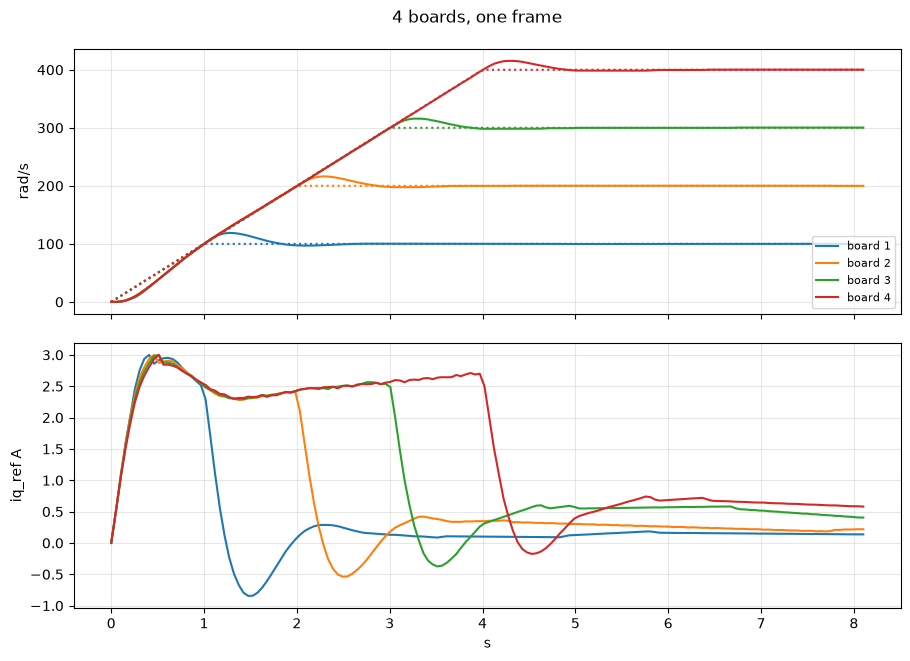

In [9]:
from coaxial.draw.figures import figure, show

fig, (speed, current) = figure(rows=2, sharex=True, title='%d boards, one frame' % len(legs))
for r in range(len(legs)):
    line, = speed.plot(log['t'][:, r], log['omega_hat'][:, r], label='board %d' % (r + 1))
    speed.plot(log['t'][:, r], log['w_ref'][:, r], ':', color=line.get_color())
    current.plot(log['t'][:, r], log['iq_ref'][:, r], color=line.get_color())
speed.set_ylabel('rad/s')
speed.legend(loc='lower right', fontsize=8)
current.set_ylabel('iq_ref A')
current.set_xlabel('s')
show(fig)

## 8 Together

The same table, `together` at half: the targets close on their mean and the boards follow; nothing in the loop changed but a number in a row.

In [10]:
TABLE[0][1]['k'] = 0.5
together_log = cyclic.run((edge,), TABLE, f, CYCLES, PERIOD)
spread = [np.ptp(log[-1]['omega_hat']), np.ptp(together_log[-1]['omega_hat'])]
print('spread across the boards: %.0f rad/s apart, %.0f together' % tuple(spread))
for leg in legs:
    leg.rig.drive.write(iq_ref=0.0)
    leg.rig.drive.off()
    leg.rig.gates.off()
    leg.rig.drive.configure(source='adc')
nodes.close()

spread across the boards: 300 rad/s apart, 0 together


## 9 Results

In [11]:
print('1. memory      %d fields x %d rows, %d B, laid once' % (len(f.dtype.names), f.size, f.nbytes))
print('2. the cycle   %d passes, %d frames lost' % (len(log), edge.lost.sum()))
print('3. held        %d boards, the worst %.1f rad/s off its target' % (len(legs), miss.max()))
print('4. together    %.0f -> %.0f rad/s apart' % tuple(spread))

1. memory      6 fields x 4 rows, 192 B, laid once
2. the cycle   160 passes, 0 frames lost
3. held        4 boards, the worst 0.3 rad/s off its target
4. together    300 -> 0 rad/s apart


- `machine.Loop` is this pass over a dict of channels, for the panel and the sequencer.
- ctrl.c is the same table on the board: a part's step by kind, `FILTERS`, `REGULATORS`.

**Bench.** The record commissioned first (`commissioning.ipynb`); `gates.on()` without flags; the model off, `source='adc'`: the frame is then the shunts.

## References

* `host/machine/cyclic.py` - `frame`, `state`, the steps, `edge`, `poll`, `push`, `run`
* `host/tests/test_cyclic.py` - the steps against machine.parts, the cycle on a toy rotor
* `ctrl/src/ctrl.c` - the same parts on the board, tables by kind
* `docs/ARCHITECTURE.md` - data-oriented design, target and host